In [ ]:
# Ensures Jupyter reloads modules whenever .py files are modified
%load_ext autoreload
%autoreload 2

This notebook assumes:

*   Extra Trees is the selected model
*   Your existing `dataset_creation.py` and `ex_random_tree.py` remain unchanged

# New Car Sales Forecast — Executive View

## Purpose
This notebook provides forward‑looking sales predictions using the selected
machine‑learning model and the most recent available data.

The goal is to support:
- demand planning
- inventory management
- production and procurement decisions

This view is designed for business stakeholders and focuses on **predictions,
confidence, and implications**, not model development details.

## Model Overview

The forecasts shown here are generated using an **Extra Trees regression model**.

This model was selected because it demonstrated:
- the lowest prediction error on unseen data
- stable performance across different time periods

A full technical comparison of all evaluated models is available in the
supporting data‑science notebook.

## Data Used

Predictions are based on historical monthly new‑car sales by manufacturer.

Key characteristics:
- Time‑series sales data
- Monthly frequency
- Uses the most recent 12 months of history per manufacturer
- Assumes historical patterns remain broadly applicable

These predictions represent **what the model would estimate if run today**
using the latest available data.

---

## 4. Load Data & Model

This section loads the most recent, cleaned sales data and initializes the
validated Extra Trees forecasting model.  
It establishes a consistent and trusted foundation for generating predictions
using the same data definitions as the technical analysis.

In [1]:
from dataprocessing.dataset_creation import import_data
from exrandomtree.ex_random_tree import train_extratrees, predict_extratrees

import pandas as pd
import numpy as np

---

## 5. Generate “Latest Available” Feature Set

This step extracts the most recent 12 months of sales history for each manufacturer
to represent the information available *today*.  
It creates the forward‑looking input used to generate forecasts without relying
on any future or unseen outcomes.

In [2]:
def latest_features(df: pd.DataFrame, x_len: int = 12) -> np.ndarray:
    """
    Extract the most recent x_len months per manufacturer
    for forward-looking predictions.
    """
    return df.iloc[:, -x_len:].values

In [3]:
df = import_data()
X_live = latest_features(df, x_len=12)

df.shape, X_live.shape

((65, 121), (65, 12))

---

## 6. Train Final Model & Generate Predictions

Here, the final model is trained on all available historical data and then applied
to the latest feature set to produce current forecasts.  
This simulates what the model would predict if it were run in an operational
setting today.

In [4]:
# Train final model on full historical data
# (same parameters as validated in the analysis notebook)

from dataprocessing.dataset_creation import datasets

X_train, Y_train, _, _ = datasets(df)

model = train_extratrees(X_train, Y_train)

# Generate forward-looking predictions
predictions = predict_extratrees(model, X_live)


---

## 7. Present Predictions (Key Output)

This section presents the forecasted monthly sales by manufacturer in a clear,
ranked table.  
The table highlights where demand is expected to be strongest and serves as the
primary decision‑support output for planning and resource allocation.

In [10]:
results = pd.DataFrame({
    "Manufacturer": df.index,
    "Predicted Sales - Next Month": predictions.round(0).astype(int)
})

results = results.sort_values("Predicted Sales - Next Month", ascending=False)
results.head(10)

,Manufacturer,Predicted Sales - Next Month
62,Volkswagen,1940
61,Toyota,1473
3,BMW,1082
63,Volvo,805
38,Mercedes-Benz,784
18,Ford,674
43,Nissan,664
2,Audi,664
52,Skoda,638
36,Mazda,493


> First column is row labels

In [11]:
total_forecast = results["Predicted Sales - Next Month"].sum()
total_forecast

12977

> The total forecasted units sold next month, summed across all manufacturers in the dataset.

---

## 8. Visual Summary

The visualization provides a simple, high‑level comparison of predicted demand
across manufacturers.  
It allows executives to quickly identify relative scale, concentration, and
top contributors without interpreting technical metrics.

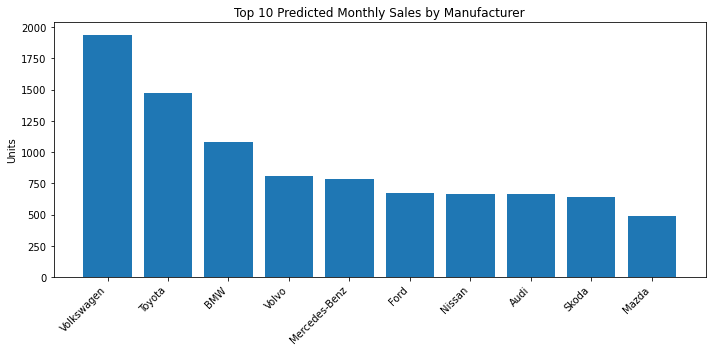

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(results["Manufacturer"].head(10),
        results["Predicted Monthly Sales"].head(10))
plt.title("Top 10 Predicted Monthly Sales by Manufacturer")
plt.ylabel("Units")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Confidence in the Forecast

Based on historical testing:
- Predictions are typically within **±17–18%** of actual sales on average.

This means:
- The forecasts are directionally reliable
- Exact monthly values should be interpreted within this expected range
- The model is best suited for planning and comparison, not precise point estimates


## Assumptions & Limitations

- The model assumes historical demand patterns remain broadly relevant
- It does not account for:
  - sudden market shocks
  - major pricing or incentive changes
  - new product launches not seen in the data

These forecasts are intended to **support decision‑making**, not replace
business judgment.

## Executive Summary

- A machine‑learning model was used to forecast monthly new‑car sales
- The model was selected based on strong out‑of‑sample performance
- Predictions were generated using the most recent available data
- Forecasts are typically accurate within ±18%
- Results can support planning, inventory, and resource allocation decisions
